# Proyecto de Regresión Supervisada — Estrategia Competitiva (MSE)

Este notebook implementa un flujo **reproducible** y orientado a **generalización** para minimizar MSE:

1. EDA técnico (estructura, faltantes, distribuciones, outliers, correlaciones, multicolinealidad).
2. Preprocesamiento con `Pipeline` + `ColumnTransformer` (sin data leakage).
3. Entrenamiento y optimización de múltiples modelos (baseline y modelos fuertes).
4. Comparación cuantitativa en validación con métrica principal **MSE**.
5. Persistencia del mejor pipeline con `pickle`.
6. Generación de `predicciones.csv` con una sola columna `SalePrice` para el archivo `test_features.csv`.

**Nota del curso:** la decisión final del modelo se basa en menor MSE.

In [11]:
import os
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)

## 1) Carga y revisión inicial de datos

In [12]:
X = pd.read_csv('data/training_features.csv')
y_df = pd.read_csv('data/training_target.csv')

if 'SalePrice' not in y_df.columns:
    raise ValueError("training_target.csv debe contener la columna 'SalePrice'")

y = y_df['SalePrice']

print('Dimensiones X:', X.shape)
print('Dimensiones y:', y.shape)
print('Tipos de variables (top):')
display(X.dtypes.value_counts())

display(X.head(3))
display(y.head(3))

Dimensiones X: (2344, 79)
Dimensiones y: (2344,)
Tipos de variables (top):


object     43
int64      25
float64    11
Name: count, dtype: int64

Dimensiones X: (2344, 79)
Dimensiones y: (2344,)
Tipos de variables (top):


object     43
int64      25
float64    11
Name: count, dtype: int64

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition
0,20,RL,80.0,10400,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,7,5,1976,1976,Gable,CompShg,HdBoard,HdBoard,BrkFace,189.0,TA,TA,CBlock,Gd,TA,No,Unf,0.0,Unf,0.0,1090.0,1090.0,GasA,TA,Y,SBrkr,1370,0,0,1370,0.0,0.0,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2.0,479.0,TA,TA,Y,0,0,0,0,0,0,NaN,MnPrv,NaN,0,6,2009,WD,Family
1,60,RL,NaN,28698,Pave,NaN,IR2,Low,AllPub,CulDSac,Sev,ClearCr,Norm,Norm,1Fam,2Story,5,5,1967,1967,Flat,Tar&Grv,Plywood,Plywood,NaN,0.0,TA,TA,PConc,TA,Gd,Gd,LwQ,249.0,ALQ,764.0,0.0,1013.0,GasA,TA,Y,SBrkr,1160,966,0,2126,0.0,1.0,2,1,3,1,TA,7,Min2,0,NaN,Attchd,1967.0,Fin,2.0,538.0,TA,TA,Y,486,0,0,0,225,0,NaN,NaN,NaN,0,6,2009,WD,Abnorml
2,90,RL,70.0,9842,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,NAmes,Norm,Norm,Duplex,1Story,4,5,1962,1962,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,TA,TA,Slab,NaN,NaN,NaN,NaN,0.0,NaN,0.0,0.0,0.0,GasA,TA,Y,SBrkr,1224,0,0,1224,0.0,0.0,2,0,2,2,TA,6,Typ,0,NaN,CarPort,1962.0,Unf,2.0,462.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,3,2007,WD,Normal


0    152000
1    185000
2    101800
Name: SalePrice, dtype: int64

In [13]:
quality_cols = ['Exter Qual', 'Kitchen Qual', 'Bsmt Qual', 'Fireplace Qu', 'Garage Qual', 'Garage Cond', 'Exter Cond', 'Heating QC', 'Bsmt Cond']
quality_map = {'NA': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}

missing = X.isna().sum().sort_values(ascending=False)
missing_ratio = (missing / len(X)).sort_values(ascending=False)
cols_to_drop_training = missing_ratio[missing_ratio > 0.80].index.tolist()

def preparar_datos(X):
    X_proc = X.copy()

    if 'cols_to_drop_training' in globals() and cols_to_drop_training:
        drop_cols = [c for c in cols_to_drop_training if c in X_proc.columns]
    else:
        missing_local = X_proc.isna().sum().sort_values(ascending=False)
        missing_ratio_local = (missing_local / len(X_proc)).sort_values(ascending=False)
        drop_cols = missing_ratio_local[missing_ratio_local > 0.80].index.tolist()

    if drop_cols:
        X_proc = X_proc.drop(columns=drop_cols)

    for col in quality_cols:
        if col in X_proc.columns:
            X_proc[col] = X_proc[col].map(quality_map).fillna(0)

    return X_proc

X = preparar_datos(X)

num_cols = X.select_dtypes(include=['number']).columns.tolist()
cat_cols = X.select_dtypes(exclude=['number']).columns.tolist()

mapped_quality_cols = [col for col in quality_cols if col in X.columns]
num_cols = list(dict.fromkeys(num_cols + mapped_quality_cols))
cat_cols = [col for col in cat_cols if col not in mapped_quality_cols]

if cols_to_drop_training:
    print(f'Se eliminaron {len(cols_to_drop_training)} columnas con más de 80% de nulos (training).')
else:
    print('No hay columnas con más de 80% de nulos (training).')

print(f'Variables numéricas: {len(num_cols)}')
print(f'Variables categóricas: {len(cat_cols)}')

missing = X.isna().sum().sort_values(ascending=False)
missing_ratio = (missing / len(X)).sort_values(ascending=False)
missing_table = pd.DataFrame({'missing_count': missing, 'missing_ratio': missing_ratio})

print('Top variables con faltantes:')
display(missing_table[missing_table['missing_count'] > 0].head(20))

print('Descripción de la variable objetivo (SalePrice):')
display(y.describe())

Se eliminaron 3 columnas con más de 80% de nulos (training).
Variables numéricas: 45
Variables categóricas: 31
Top variables con faltantes:


Se eliminaron 3 columnas con más de 80% de nulos (training).
Variables numéricas: 45
Variables categóricas: 31
Top variables con faltantes:


,missing_count,missing_ratio
Fence,1874,0.799488
Mas Vnr Type,1426,0.608362
Lot Frontage,393,0.167662
Garage Yr Blt,122,0.052048
Garage Finish,122,0.052048
Garage Type,120,0.051195
Bsmt Exposure,63,0.026877
BsmtFin Type 2,62,0.026451
BsmtFin Type 1,61,0.026024
Mas Vnr Area,19,0.008106


Descripción de la variable objetivo (SalePrice):


count      2344.000000
mean     178582.207765
std       77125.072713
min       12789.000000
25%      129000.000000
50%      160000.000000
75%      210000.000000
max      755000.000000
Name: SalePrice, dtype: float64

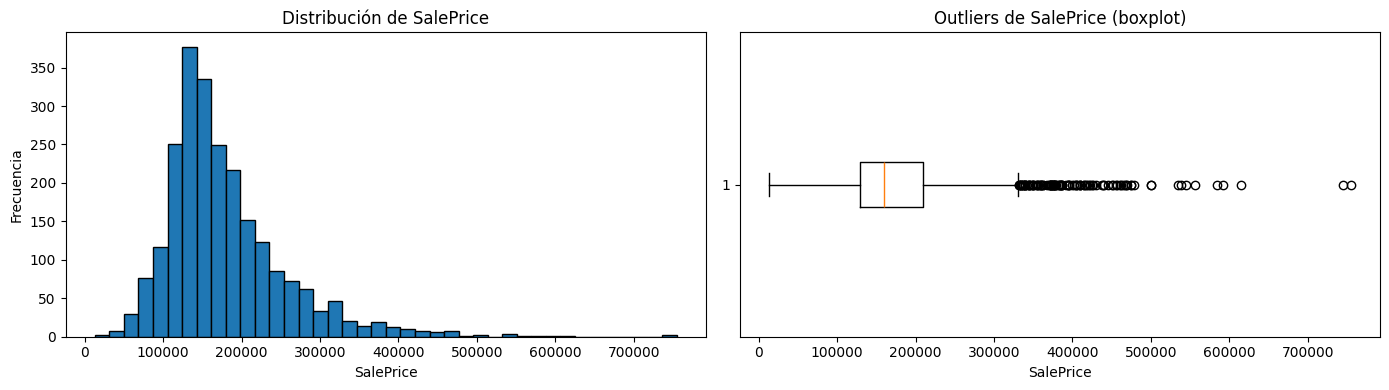

Outliers en target según IQR: 107 (4.56%)


In [14]:
# Distribución de target
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(y, bins=40, edgecolor='black')
axes[0].set_title('Distribución de SalePrice')
axes[0].set_xlabel('SalePrice')
axes[0].set_ylabel('Frecuencia')

axes[1].boxplot(y, vert=False)
axes[1].set_title('Outliers de SalePrice (boxplot)')
axes[1].set_xlabel('SalePrice')

plt.tight_layout()
plt.show()

# Outliers por criterio IQR solo para el target
q1, q3 = y.quantile(0.25), y.quantile(0.75)
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outliers_target = ((y < lower) | (y > upper)).sum()
print(f'Outliers en target según IQR: {outliers_target} ({outliers_target/len(y):.2%})')

Top correlaciones positivas con SalePrice:


Top correlaciones positivas con SalePrice:


Overall Qual     0.795298
Gr Liv Area      0.698315
Exter Qual       0.685320
Kitchen Qual     0.661169
Garage Cars      0.644304
Garage Area      0.633106
Total Bsmt SF    0.612256
1st Flr SF       0.607433
Bsmt Qual        0.601646
Year Built       0.545409
Full Bath        0.542053
Fireplace Qu     0.523974
Name: SalePrice, dtype: float64

Top correlaciones negativas con SalePrice:


3Ssn Porch         0.034845
Mo Sold            0.030714
BsmtFin SF 2       0.027205
Exter Cond         0.020524
Low Qual Fin SF   -0.016025
Misc Val          -0.017729
Bsmt Half Bath    -0.023675
Yr Sold           -0.037686
MS SubClass       -0.066351
Overall Cond      -0.104085
Kitchen AbvGr     -0.115860
Enclosed Porch    -0.130722
Name: SalePrice, dtype: float64

...

Overall Qual     0.795298
Gr Liv Area      0.698315
Exter Qual       0.685320
Kitchen Qual     0.661169
Garage Cars      0.644304
Garage Area      0.633106
Total Bsmt SF    0.612256
1st Flr SF       0.607433
Bsmt Qual        0.601646
Year Built       0.545409
Full Bath        0.542053
Fireplace Qu     0.523974
Name: SalePrice, dtype: float64

Top correlaciones negativas con SalePrice:


3Ssn Porch         0.034845
Mo Sold            0.030714
BsmtFin SF 2       0.027205
Exter Cond         0.020524
Low Qual Fin SF   -0.016025
Misc Val          -0.017729
Bsmt Half Bath    -0.023675
Yr Sold           -0.037686
MS SubClass       -0.066351
Overall Cond      -0.104085
Kitchen AbvGr     -0.115860
Enclosed Porch    -0.130722
Name: SalePrice, dtype: float64

Pares con correlación >= 0.85: 3


Garage Qual  Garage Cond     0.944811
Garage Cars  Garage Area     0.883871
Fireplaces   Fireplace Qu    0.858596
dtype: float64

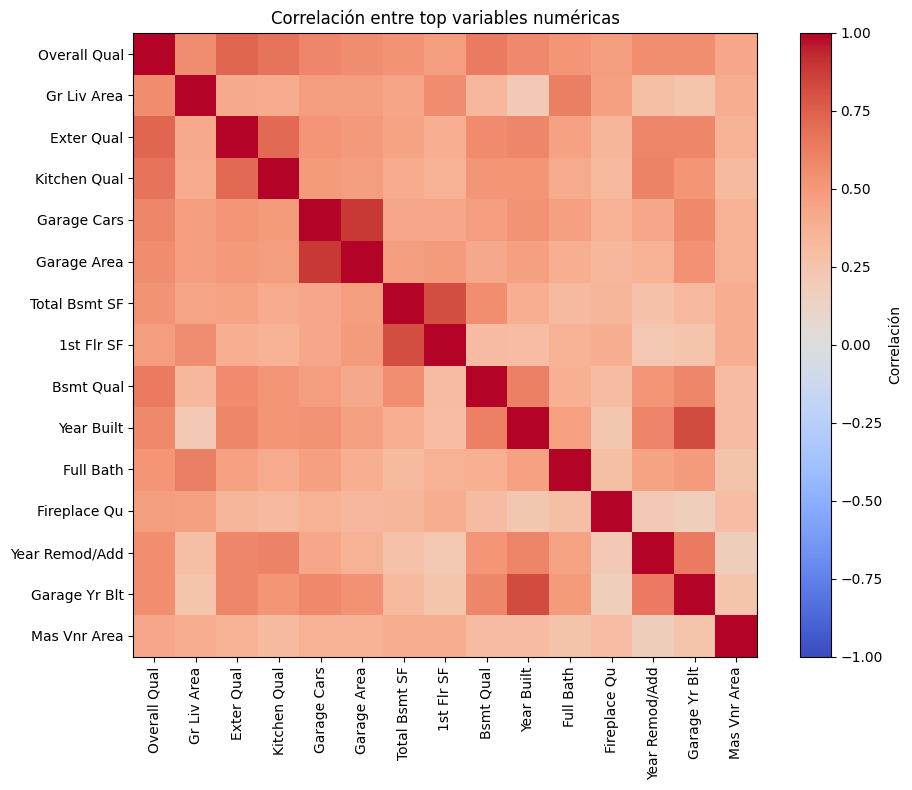

In [15]:
# Correlación con target (solo numéricas)
corr_with_target = X[num_cols].assign(SalePrice=y).corr(numeric_only=True)['SalePrice'].drop('SalePrice').sort_values(ascending=False)
print('Top correlaciones positivas con SalePrice:')
display(corr_with_target.head(12))
print('Top correlaciones negativas con SalePrice:')
display(corr_with_target.tail(12))

# Multicolinealidad aproximada: pares numéricos altamente correlacionados
corr_num = X[num_cols].corr().abs()
upper_triangle = corr_num.where(np.triu(np.ones(corr_num.shape), k=1).astype(bool))
high_corr_pairs = (
    upper_triangle.stack()
    .sort_values(ascending=False)
    .loc[lambda s: s >= 0.85]
)

print(f'Pares con correlación >= 0.85: {len(high_corr_pairs)}')
display(high_corr_pairs.head(20))

# Heatmap básico (matplotlib) de top variables por correlación absoluta a target
top_features = corr_with_target.abs().sort_values(ascending=False).head(15).index.tolist()
heat_df = X[top_features].corr()

plt.figure(figsize=(10, 8))
plt.imshow(heat_df, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlación')
plt.xticks(range(len(top_features)), top_features, rotation=90)
plt.yticks(range(len(top_features)), top_features)
plt.title('Correlación entre top variables numéricas')
plt.tight_layout()
plt.show()

## 2) División de datos y prevención de data leakage

- Se separa en **train/validation**.
- La evaluación final del experimento usa exclusivamente validation.
- El preprocesamiento se ajusta **solo con train** porque está dentro de `Pipeline`.
- `cv=5` en búsqueda de hiperparámetros estima desempeño promedio y reduce dependencia de una sola partición.

In [16]:
y = np.log1p(y)

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print('Train:', X_train.shape, y_train.shape)
print('Validation:', X_val.shape, y_val.shape)

Train: (1875, 76) (1875,)
Validation: (469, 76) (469,)


## 3) Preprocesamiento dentro de Pipeline

Decisiones técnicas:

- Numéricas: imputación por mediana + escalamiento (`StandardScaler`) para estabilidad del modelo lineal.
- Categóricas: imputación por moda + `OneHotEncoder(handle_unknown='ignore')`.
- Se evita `OrdinalEncoder` porque la mayoría de categorías no tienen orden natural y puede inducir relaciones falsas.
- El mismo `preprocessor` se comparte entre modelos para comparación justa.

In [17]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols),
    ]
)

def compute_metrics(y_true, y_pred):
    y_true = np.expm1(y_true)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mse, rmse, mae, r2

## 4) Entrenamiento y optimización de modelos

Modelos incluidos:

- **Baseline interpretable:** `Ridge` (regularización L2 para mitigar multicolinealidad).
- **Modelo fuerte:** `RandomForestRegressor` con `RandomizedSearchCV`.
- **Modelo adicional:** `GradientBoostingRegressor` con búsqueda aleatoria moderada.

Todos optimizan `scoring='neg_mean_squared_error'` con `cv=5`.

In [18]:
ridge_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge(random_state=RANDOM_STATE))
])

rf_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))
])

gbr_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(random_state=RANDOM_STATE))
])

grid_ridge = GridSearchCV(
    estimator=ridge_pipe,
    param_grid={
        'model__alpha': np.logspace(-2, 3, 12)
    },
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1
)

search_rf = RandomizedSearchCV(
    estimator=rf_pipe,
    param_distributions={
        'model__n_estimators': [300, 500, 800, 1000],
        'model__max_depth': [None, 10, 20, 30, 40],
        'model__min_samples_split': [2, 5, 10, 20],
        'model__min_samples_leaf': [1, 2, 4, 8],
        'model__max_features': ['sqrt', 'log2', 0.5, 0.8]
    },
    n_iter=40,
    scoring='neg_mean_squared_error',
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

search_gbr = RandomizedSearchCV(
    estimator=gbr_pipe,
    param_distributions={
        'model__n_estimators': [200, 400, 600, 900],
        'model__learning_rate': [0.01, 0.03, 0.05, 0.1],
        'model__max_depth': [2, 3, 4, 5],
        'model__min_samples_leaf': [1, 3, 5, 10],
        'model__subsample': [0.6, 0.8, 1.0]
    },
    n_iter=30,
    scoring='neg_mean_squared_error',
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

searches = {
    'Ridge': grid_ridge,
    'RandomForest': search_rf,
    'GradientBoosting': search_gbr
}

rows = []
best_estimators = {}

for name, search in searches.items():
    print(f'Entrenando {name}...')
    search.fit(X_train, y_train)
    best_estimators[name] = search.best_estimator_

    y_val_pred = np.expm1(search.best_estimator_.predict(X_val))
    val_mse, val_rmse, val_mae, val_r2 = compute_metrics(y_val, y_val_pred)

    rows.append({
        'Modelo': name,
        'CV_MSE_promedio': -search.best_score_,
        'VAL_MSE': val_mse,
        'VAL_RMSE': val_rmse,
        'VAL_MAE': val_mae,
        'VAL_R2': val_r2,
        'Best_Params': search.best_params_
    })

results = pd.DataFrame(rows).sort_values('VAL_MSE').reset_index(drop=True)
display(results)

best_model_name = results.loc[0, 'Modelo']
best_model = best_estimators[best_model_name]

print(f'\nMejor modelo por VAL_MSE: {best_model_name}')
print(f"VAL_MSE ganador: {results.loc[0, 'VAL_MSE']:.4f}")

Entrenando Ridge...
Entrenando RandomForest...


Entrenando Ridge...
Entrenando RandomForest...


KeyboardInterrupt: 

,Modelo,CV_MSE_promedio,VAL_MSE,Gap_Val_minus_CV_MSE
0,GradientBoosting,0.018569,3.270100e+08,3.270100e+08
1,RandomForest,0.021701,3.715136e+08,3.715136e+08
2,Ridge,0.024927,3.932514e+08,3.932514e+08


Top 15 importancias de variables:


num__Overall Qual      0.375909
num__Gr Liv Area       0.130604
num__Kitchen Qual      0.042187
num__Total Bsmt SF     0.032600
num__Garage Area       0.031273
num__Year Built        0.030110
num__Exter Qual        0.028870
num__1st Flr SF        0.028695
num__Garage Cars       0.025547
num__Lot Area          0.020634
num__Bsmt Qual         0.019849
num__BsmtFin SF 1      0.019101
num__Year Remod/Add    0.018161
num__Overall Cond      0.013488
cat__Paved Drive_N     0.008739
dtype: float64

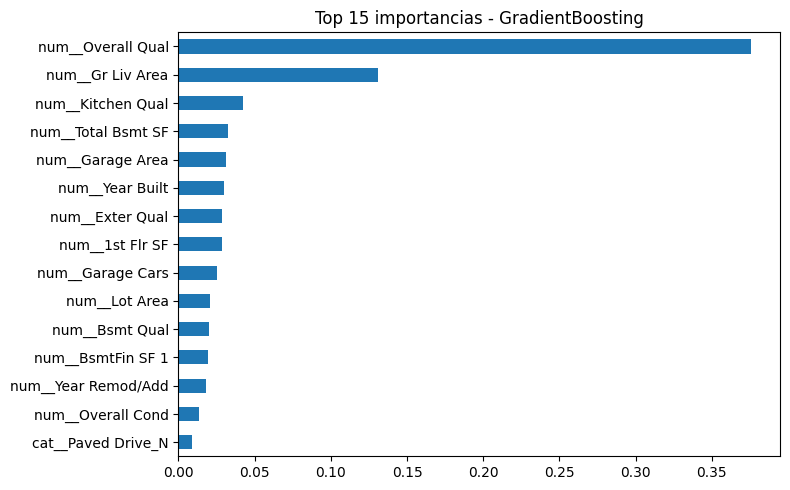

Modelo guardado en: artifacts/best_model_pipeline.pkl


In [ ]:
results['Gap_Val_minus_CV_MSE'] = results['VAL_MSE'] - results['CV_MSE_promedio']
display(results[['Modelo', 'CV_MSE_promedio', 'VAL_MSE', 'Gap_Val_minus_CV_MSE']].sort_values('VAL_MSE'))

if best_model_name == 'Ridge':
    feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
    coefs = best_model.named_steps['model'].coef_
    coef_series = pd.Series(coefs, index=feature_names).sort_values(key=np.abs, ascending=False)
    print('Top 15 coeficientes absolutos (Ridge):')
    display(coef_series.head(15))
elif best_model_name in ['RandomForest', 'GradientBoosting']:
    feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
    importances = best_model.named_steps['model'].feature_importances_
    imp_series = pd.Series(importances, index=feature_names).sort_values(ascending=False)
    print('Top 15 importancias de variables:')
    display(imp_series.head(15))

    plt.figure(figsize=(8, 5))
    imp_series.head(15).sort_values().plot(kind='barh')
    plt.title(f'Top 15 importancias - {best_model_name}')
    plt.tight_layout()
    plt.show()

model_artifact = {
    'model_name': best_model_name,
    'pipeline': best_model,
    'features_used': X.columns.tolist(),
    'cols_to_drop_training': cols_to_drop_training,
    'random_state': RANDOM_STATE
}

os.makedirs('artifacts', exist_ok=True)
model_path = 'artifacts/best_model_pipeline.pkl'

with open(model_path, 'wb') as f:
    pickle.dump(model_artifact, f)

print(f'Modelo guardado en: {model_path}')

def generar_predicciones_para_entrega(
    test_features_path='data/test_features.csv',
    output_path='predicciones.csv',
    model_pickle_path='artifacts/best_model_pipeline.pkl',
):
    if not os.path.exists(test_features_path):
        print(f'No existe {test_features_path}. Cuando lo tengas, ejecuta esta función.')
        return None

    with open(model_pickle_path, 'rb') as f:
        artifact = pickle.load(f)

    global cols_to_drop_training
    cols_to_drop_training = artifact.get('cols_to_drop_training', cols_to_drop_training)

    model = artifact['pipeline']
    expected_features = artifact['features_used']

    X_test_new = pd.read_csv(test_features_path)
    X_test_new = preparar_datos(X_test_new)

    missing_cols = [c for c in expected_features if c not in X_test_new.columns]
    if missing_cols:
        raise ValueError(f'Faltan columnas en test_features: {missing_cols[:10]}')

    X_test_new = X_test_new[expected_features]
    preds = np.expm1(model.predict(X_test_new))
    submission = pd.DataFrame({'SalePrice': preds})
    submission.to_csv(output_path, index=False)
    print(f'Archivo generado: {output_path} con forma {submission.shape}')
    return submission

In [19]:
import os
import pickle
import pandas as pd

test_path = 'data/test_features.csv'
model_path = 'artifacts/best_model_pipeline.pkl'
output_path = 'predicciones.csv'

if not os.path.exists(test_path):
    print('Aún no existe data/test_features.csv.')
elif not os.path.exists(model_path):
    print('No existe artifacts/best_model_pipeline.pkl. Ejecuta primero el entrenamiento.')
else:
    with open(model_path, 'rb') as f:
        artifact = pickle.load(f)

    global cols_to_drop_training
    cols_to_drop_training = artifact.get('cols_to_drop_training', cols_to_drop_training)

    X_test = pd.read_csv(test_path)
    X_test = preparar_datos(X_test)

    num_cols_test = X_test.select_dtypes(include=['number']).columns.tolist()
    cat_cols_test = X_test.select_dtypes(exclude=['number']).columns.tolist()
    mapped_quality_cols_test = [col for col in quality_cols if col in X_test.columns]
    num_cols_test = list(dict.fromkeys(num_cols_test + mapped_quality_cols_test))
    cat_cols_test = [col for col in cat_cols_test if col not in mapped_quality_cols_test]

    print(f'Test - Variables numéricas: {len(num_cols_test)}')
    print(f'Test - Variables categóricas: {len(cat_cols_test)}')

    model = artifact['pipeline']
    expected_features = artifact['features_used']

    missing_cols = [c for c in expected_features if c not in X_test.columns]
    if missing_cols:
        raise ValueError(f'Faltan columnas en test_features tras preparar_datos: {missing_cols[:10]}')

    X_test = X_test[expected_features]
    pred_log = model.predict(X_test)
    pred_original_scale = np.expm1(pred_log)

    submission = pd.DataFrame({'SalePrice': pred_original_scale})
    submission.to_csv(output_path, index=False)

    assert list(submission.columns) == ['SalePrice'], 'La columna debe llamarse exactamente SalePrice'
    assert submission.shape[1] == 1, 'Debe haber exactamente una sola columna'
    assert len(submission) == len(pd.read_csv(test_path)), 'El número de filas no coincide con test_features.csv'
    assert submission['SalePrice'].isna().sum() == 0, 'Hay valores faltantes en las predicciones'

    print('predicciones.csv listo para subir.')
    print(submission.head())

Test - Variables numéricas: 45
Test - Variables categóricas: 31
predicciones.csv listo para subir.
       SalePrice
0  132225.549527
1  163075.533965
2   84289.544023
3   83439.394857
4   93744.258774
